# Reproducing "Massive Activations" Figure 1 — Llama-3.1-8B-Instruct

Reproduces the diagnostic from Sun, Chen, Kolter & Liu, *Massive Activations in Large Language Models* (COLM 2024),
for **Llama-3.1-8B-Instruct**, loaded directly via `transformers` (no TransformerLens).

Definitions follow the paper exactly:
- The residual stream at layer $\ell$ is $h_\ell \in \mathbb{R}^{T \times d}$ (output of the residual sum, i.e. the
  block output, **not** an intermediate attention/MLP activation).
- An "activation" is a single scalar $h_\ell[t, i]$ — one (token position, feature dimension) pair.
- A massive activation (MA) is defined (loosely) as $|h_\ell[t,i]| > 100$ and roughly $\geq 1000\times$ the median
  $|h_\ell[:, :]|$ magnitude for that layer.

We get every $h_\ell$ in a single forward pass via `output_hidden_states=True` — this is the standard HF hidden-state
stack, so no monkey-patching / custom decoder layers are needed (unlike the paper's own repo).

In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3d projection)
from transformers import AutoModelForCausalLM, AutoTokenizer

print("torch", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch 2.2.2+cu121
cuda available: True


## Config

In [2]:
MODEL_PATH = "/home/samuel/research/llmattacks/llm-attacks/DIR/Llama-3.1-8B-Instruct"

# Paper's illustrative probe sentence (Figure 1). You can swap in your own refusal-related prompts later.
SEQ = "Summer is warm. Winter is cold."

# Paper turns OFF the tokenizer's automatic BOS prepending for the Figure-1 illustration
# (add_special_tokens=False in the official repo's main_llm.py). Set to True to include BOS
# and see how the starting-token massive activation lines up with an explicit <|begin_of_text|>.
ADD_SPECIAL_TOKENS = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32

## Load model and tokenizer

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=DTYPE,
    device_map=DEVICE,
)
model.eval()

num_layers = model.config.num_hidden_layers
hidden_size = model.config.hidden_size
print(f"num_layers={num_layers}, hidden_size={hidden_size}, device={DEVICE}, dtype={DTYPE}")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

num_layers=32, hidden_size=4096, device=cuda, dtype=torch.bfloat16


## Single forward pass, capturing every $h_\ell$

`output_hidden_states=True` returns a tuple of length `num_layers + 1`:
- `hidden_states[0]` = embedding output (before any transformer block, i.e. $h_0$)
- `hidden_states[l]` = residual-stream output **after** decoder layer `l` (i.e. $h_l$, matching the paper's indexing,
  $\ell = 1 \dots L$)

This is exactly the tensor the paper's own repo captures via its monkey-patched `layer.feat` — here we get all layers
in one pass instead of patching layer-by-layer.

In [4]:
input_ids = tokenizer(SEQ, return_tensors="pt", add_special_tokens=ADD_SPECIAL_TOKENS).input_ids.to(DEVICE)

tokens_decoded = [tokenizer.decode(input_ids[0, i].item()) for i in range(input_ids.shape[1])]
print("tokens:", tokens_decoded)

with torch.no_grad():
    out = model(input_ids, output_hidden_states=True)

hidden_states = out.hidden_states  # tuple: len == num_layers + 1, each (1, T, d)
print("num hidden_states tensors:", len(hidden_states))
print("shape of each:", hidden_states[0].shape)

tokens: ['Summer', ' is', ' warm', '.', ' Winter', ' is', ' cold', '.']
num hidden_states tensors: 33
shape of each: torch.Size([1, 8, 4096])


In [ ]:
import numpy as np
import os

input_ids = tokenizer(SEQ, return_tensors="pt", add_special_tokens=ADD_SPECIAL_TOKENS).input_ids.to(DEVICE)
tokens_decoded = [tokenizer.decode(input_ids[0, i].item()) for i in range(input_ids.shape[1])]
print("tokens:", tokens_decoded)
with torch.no_grad():
    out = model(input_ids, output_hidden_states=True)
hidden_states = out.hidden_states  # tuple: len == num_layers + 1, each (1, T, d)
print("num hidden_states tensors:", len(hidden_states))
print("shape of each:", hidden_states[0].shape)

# # --- Stack all layers into a single (num_layers+1, T, d) float32 array ---
# OUTPUT_DIR = "hidden_states_npy"  # change to your preferred path
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# # Squeeze batch dim from each (1, T, d) -> (T, d), cast to float32, then stack -> (33, T, d)
# stacked = np.stack(
#     [h.squeeze(0).to(torch.float32).cpu().numpy() for h in hidden_states],
#     axis=0
# )
# assert stacked.dtype == np.float32
# print("stacked shape:", stacked.shape)  # (33, 8, 4096)

# fname = os.path.join(OUTPUT_DIR, "hidden_states_all_layers.npy")
# np.save(fname, stacked)
# print(f"Saved combined array to {fname}, shape {stacked.shape}, dtype {stacked.dtype}")

tokens: ['Summer', ' is', ' warm', '.', ' Winter', ' is', ' cold', '.']
num hidden_states tensors: 33
shape of each: torch.Size([1, 8, 4096])
stacked shape: (33, 8, 4096)
Saved combined array to hidden_states_npy/hidden_states_all_layers.npy, shape (33, 8, 4096), dtype float32


## Layerwise scan: find where massive activations emerge

Reproduces the depth-wise summary behind Table 1 / Appendix A.4: for each layer, the top-5 |activation| values and
the median |activation|, taken over all $T \times d$ scalar entries. Massive activations should appear as an abrupt
jump in the top-1/top-2 curve after an early layer, and persist until dropping off near the final layers.

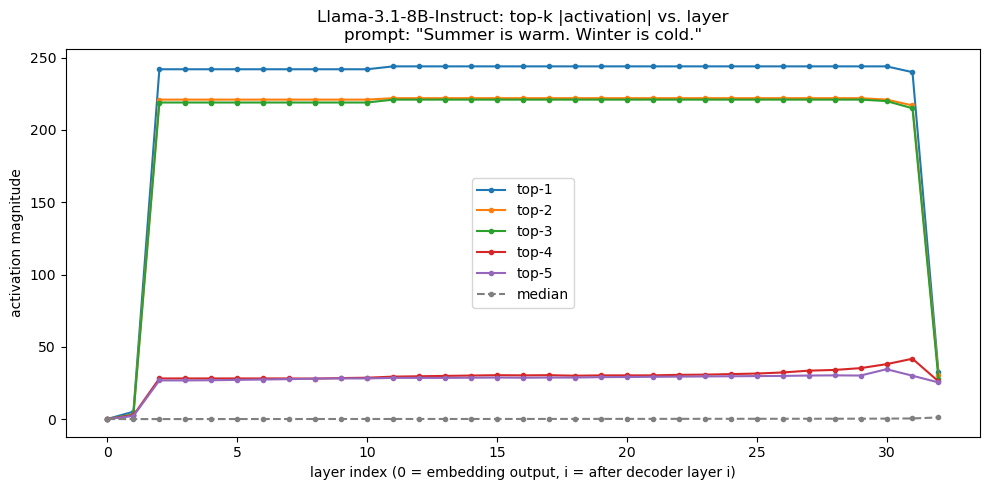

Layer with largest top-1 |activation|: 11 (value=244.0, median=0.073, ratio=3331x)


In [6]:
stats = np.zeros((6, len(hidden_states)))  # rows: top1..top5, median

for l, h in enumerate(hidden_states):
    feat_abs = h[0].float().abs()  # (T, d)
    flat_sorted, _ = torch.sort(feat_abs.flatten(), descending=True)
    
    stats[:5, l] = flat_sorted[:5].cpu().numpy()
    stats[5, l] = feat_abs.median().item()
    # print(stats[:5, l])

layer_axis = np.arange(len(hidden_states))  # 0 = embeddings, 1..L = after each decoder layer

fig, ax = plt.subplots(figsize=(10, 5))
for i, label in enumerate(["top-1", "top-2", "top-3", "top-4", "top-5"]):
    ax.plot(layer_axis, stats[i], marker="o", markersize=3, label=label)
ax.plot(layer_axis, stats[5], marker="o", markersize=3, label="median", linestyle="--", color="gray")
ax.set_xlabel("layer index (0 = embedding output, i = after decoder layer i)")
ax.set_ylabel("activation magnitude")
# ax.set_yscale("log")
ax.set_title(f"Llama-3.1-8B-Instruct: top-k |activation| vs. layer\nprompt: \"{SEQ}\"")
ax.legend()
plt.tight_layout()
plt.show()

best_layer = int(np.argmax(stats[0]))
print(f"Layer with largest top-1 |activation|: {best_layer} "
      f"(value={stats[0, best_layer]:.1f}, median={stats[5, best_layer]:.3f}, "
      f"ratio={stats[0, best_layer] / max(stats[5, best_layer], 1e-8):.0f}x)")

## Identify the massive-activation (token, feature-dim) coordinates

Using the paper's criterion: $|h_\ell[t,i]| > 100$ **and** $\geq \sim 1000\times$ the layer's median magnitude.

In [7]:
def find_massive_activations(h, abs_thresh=100.0, ratio_thresh=1000.0):
    """h: (T, d) tensor for a single layer. Returns list of (token_idx, feat_idx, value)."""
    feat_abs = h.float().abs()
    med = feat_abs.median().item()
    mask = (feat_abs > abs_thresh) & (feat_abs > ratio_thresh * med)
    idxs = torch.nonzero(mask, as_tuple=False)
    results = [(int(t), int(i), feat_abs[t, i].item()) for t, i in idxs]
    results.sort(key=lambda r: -r[2])
    return results, med

LAYER_ID = best_layer  # override manually if you want to inspect a specific layer instead
h_l = hidden_states[LAYER_ID][0]  # (T, d)

mas, layer_median = find_massive_activations(h_l)
print(f"Layer {LAYER_ID} — median |activation| = {layer_median:.4f}")
print(f"Found {len(mas)} massive activation(s):")
for t, i, v in mas:
    print(f"  token[{t}]=\"{tokens_decoded[t]}\"  feature_dim={i}  |activation|={v:.1f}")

Layer 11 — median |activation| = 0.0732
Found 3 massive activation(s):
  token[0]="Summer"  feature_dim=788  |activation|=244.0
  token[0]="Summer"  feature_dim=1384  |activation|=222.0
  token[0]="Summer"  feature_dim=4062  |activation|=221.0


## 3D bar plot (reproducing Figure 1 style)

x-axis: feature dimension, y-axis: token position (labeled with decoded tokens), z-axis: activation magnitude.

Plotting all `hidden_size` (4096 or more) bars per token is expensive to render as individual `bar3d` calls, so we
plot every feature dimension but as a single fast `bar3d` batch call (matches the paper's dense "skyline" look).

/tmp/ipykernel_3053664/3509196410.py:29: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


saved to llama31_8b_instruct_massive_activations_layer11.png


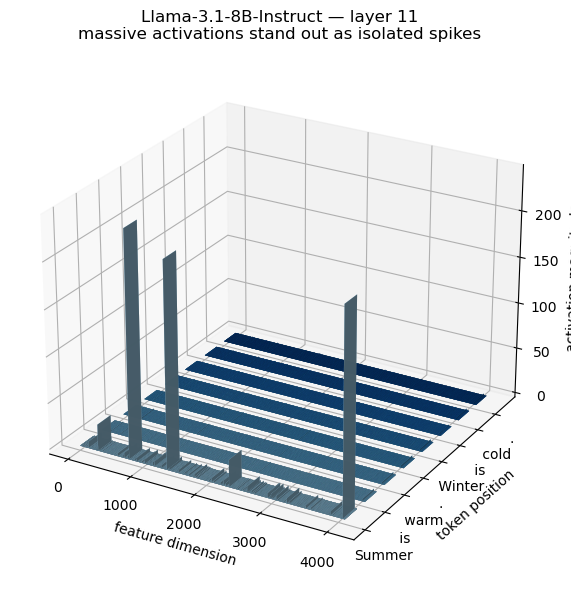

In [8]:
def plot_3d_feat(h, tokens_decoded, layer_id, model_name, savepath=None, elev=25, azim=-60):
    """h: (T, d) tensor (already moved to CPU, float)."""
    feat_abs = h.float().abs().cpu().numpy()
    T, d = feat_abs.shape

    fig = plt.figure(figsize=(11, 7))
    ax = fig.add_subplot(111, projection="3d")

    xs = np.arange(d)
    dx = np.ones(d) * 1.0
    dy = np.ones(d) * 0.6
 
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, T))

    for t in range(T):
        ys = np.full(d, t)
        zs = np.zeros(d)
        dz = feat_abs[t]
        ax.bar3d(xs, ys, zs, dx, dy, dz, color=colors[t], shade=True, edgecolor="none", alpha=0.9)

    ax.set_xlabel("feature dimension")
    ax.set_ylabel("token position")
    ax.set_zlabel("activation magnitude")
    ax.set_yticks(np.arange(T))
    ax.set_yticklabels(tokens_decoded)
    ax.set_title(f"{model_name} — layer {layer_id}\nmassive activations stand out as isolated spikes")
    ax.view_init(elev=elev, azim=azim)

    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath, dpi=200, bbox_inches="tight")
        print(f"saved to {savepath}")
    plt.show()

plot_3d_feat(
    h_l.cpu(),
    tokens_decoded,
    LAYER_ID,
    "Llama-3.1-8B-Instruct",
    savepath="llama31_8b_instruct_massive_activations_layer%d.png" % LAYER_ID,
)

## Zoomed view around the massive-activation coordinates only

The full-range plot above makes the spikes visible, but everything else is squashed near z=0. This zooms x onto a
window around each identified massive-activation feature dimension for a clearer read of exact values.

/tmp/ipykernel_3053664/3991937032.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


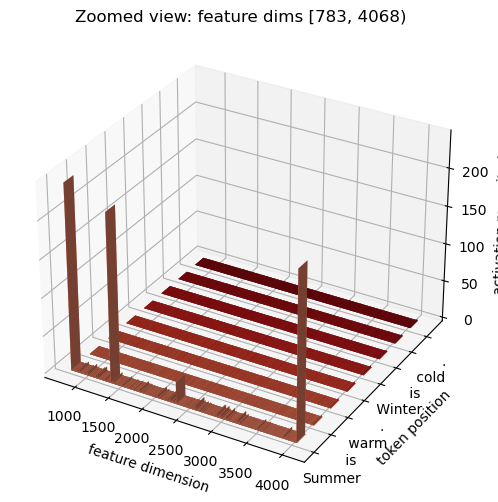

In [9]:
if len(mas) > 0:
    feat_dims = sorted(set(i for _, i, _ in mas))
    window = 5
    lo = max(0, min(feat_dims) - window)
    hi = min(hidden_size, max(feat_dims) + window + 1)

    h_zoom = h_l[:, lo:hi].cpu()
    tokens_zoom = tokens_decoded

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection="3d")
    feat_abs = h_zoom.float().abs().numpy()
    T, d = feat_abs.shape
    xs = np.arange(lo, hi)
    dx = np.ones(d) * 0.8
    dy = np.ones(d) * 0.5
    colors = plt.cm.Reds(np.linspace(0.4, 0.9, T))

    for t in range(T):
        ys = np.full(d, t)
        zs = np.zeros(d)
        dz = feat_abs[t]
        ax.bar3d(xs, ys, zs, dx, dy, dz, color=colors[t], shade=True, edgecolor="none", alpha=0.9)

    ax.set_xlabel("feature dimension")
    ax.set_ylabel("token position")
    ax.set_zlabel("activation magnitude")
    ax.set_yticks(np.arange(T))
    ax.set_yticklabels(tokens_zoom)
    ax.set_title(f"Zoomed view: feature dims [{lo}, {hi})")
    plt.tight_layout()
    plt.show()
else:
    print("No massive activations found at this layer under the current threshold — try a different LAYER_ID "
          "(see the layerwise scan above) or relax abs_thresh/ratio_thresh.")

## Notes

- If you want the BOS-prepended version (paper's Appendix A.3 finding: MA locations can shift with an explicit
  `<|begin_of_text|>`), set `ADD_SPECIAL_TOKENS = True` and re-run from the tokenization cell.
- The layerwise scan already gives you the depth curve for free (no extra passes needed) — useful if you want the
  Table-1-style summary for a range of prompts rather than a single sentence; just wrap the forward pass in a loop
  over prompts and average/aggregate `stats`.
- For your refusal-direction work specifically: once you have `feat_dims` (the massive-activation feature indices)
  for Llama-3.1-8B-Instruct, it's worth checking the cosine alignment / loading of your DIM direction and top
  Jacobian singular vector `v_1` on exactly those coordinates, since they carry outsized norm independent of
  semantic content.